# ResistFlow - Demo Notebook

This notebook demonstrates the core ResistFlow simulation framework.

It runs three intervention scenarios and visualises how resistance allele 
frequency evolves over time under different insecticide pressure assumptions.

**Scenarios compared:**
- Baseline: no insecticide pressure, pure genetic drift
- Continuous pressure: sustained pyrethroid application
- Reduced coverage: partial insecticide coverage

A MalariaGEN-backed validation case (Vgsc-1014F, Burkina Faso) will be 
added once data integration is implemented.

In [1]:
from resistflow.simulation.wright_fisher import simulate
from resistflow.scenarios.presets import get_scenario
from resistflow.visualization.plots import plot_trajectories, plot_scenario_comparison

In [2]:
# Simulation parameters
N = 10_000          # effective population size
n_generations = 80  # 8 years at 10 generations per year
n_replicates = 20   # 20 runs to show drift variance
generations_per_year = 10

# Run each scenario
results = {}
for scenario_name in ["baseline", "continuous_pressure", "reduced_coverage"]:
    params = get_scenario(scenario_name)
    results[scenario_name] = simulate(
        p0=0.24,
        N=N,
        n_generations=n_generations,
        w_AA=params["w_AA"],
        w_Aa=params["w_Aa"],
        w_aa=params["w_aa"],
        n_replicates=n_replicates,
    )

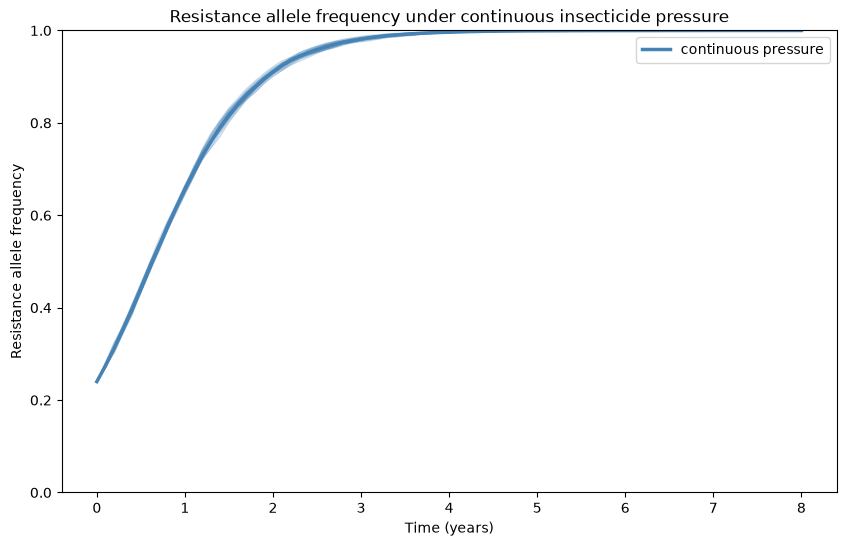

In [3]:
ax = plot_trajectories(
    trajectories=results["continuous_pressure"],
    generations_per_year=generations_per_year,
    title="Resistance allele frequency under continuous insecticide pressure",
    scenario_label="continuous pressure",
)

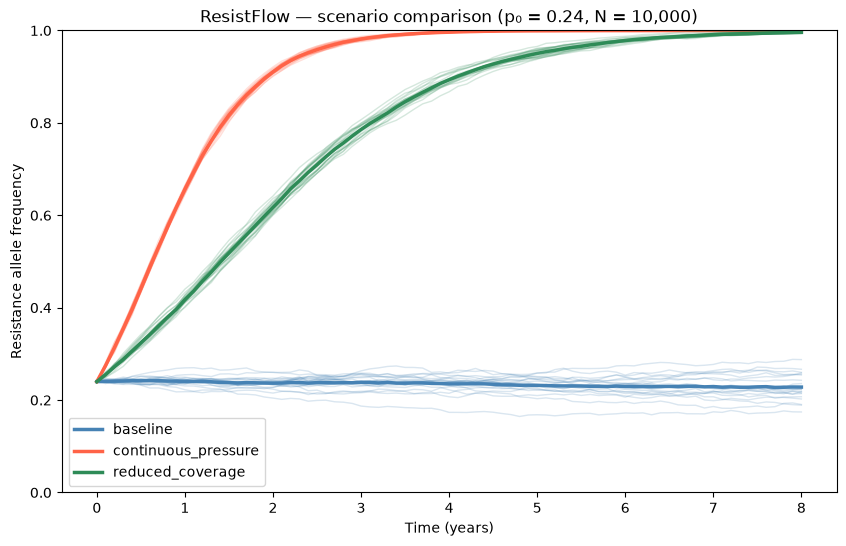

In [4]:
fig = plot_scenario_comparison(
    results_by_scenario=results,
    generations_per_year=generations_per_year,
    title="ResistFlow — scenario comparison (p₀ = 0.24, N = 10,000)",
)

## MalariaGEN validation case (planned)

This section will initialize the simulation from real Vgsc-1014F allele 
frequency data for Burkina Faso (2012 baseline: ~24%) and compare the 
simulated trajectory against the observed 2020 frequency (~68%).

*Requires MalariaGEN data integration — see `src/resistflow/data/malariagen.py`.*